In [162]:
# Inisialisasi Direktori dan Konstanta Proyek
import os

DATASET_DIR = "dataset"
MODEL_DIR = "model"

os.makedirs(MODEL_DIR, exist_ok=True)

In [163]:
# Memuat Dataset Caption Gambar
import os
import pandas as pd

def load_captions():
    path = os.path.join(DATASET_DIR, "captions.xlsx")
    df = pd.read_excel(path)
    df.columns = df.columns.str.lower()
    df["caption"] = df["caption"].astype(str)
    return df


In [164]:
# Preprocessing Teks Caption
def clean_caption(text):
    text = text.lower().strip()
    text = ''.join(c for c in text if c.isalnum() or c.isspace())
    return f"startseq {text} endseq"

In [165]:
# Pembersihan dan Persiapan Data Caption
df = load_captions()
df["cleaned"] = df["caption"].apply(clean_caption)

captions = df["cleaned"].tolist()
filenames = df["filename"].tolist()


In [166]:
# Fungsi Ekstraksi Fitur Gambar
import numpy as np
from PIL import Image
from tensorflow.keras.applications.inception_v3 import preprocess_input

def extract_feature(img_path, model):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((299, 299))
    x = np.expand_dims(np.array(img), axis=0)
    x = preprocess_input(x)
    feat = model.predict(x, verbose=0)
    return feat.flatten()


In [167]:
# Inisialisasi Model CNN (InceptionV3) sebagai Encoder
from tensorflow.keras.applications.inception_v3 import InceptionV3

extractor = InceptionV3(
    include_top=False,
    weights="imagenet",
    pooling="avg"
)


In [168]:
# Ekstraksi Fitur Gambar dari Dataset
import os
import numpy as np

features = []
clean_caps = []

img_dir = os.path.join(DATASET_DIR, "images")

for i, fname in enumerate(filenames):
    img_path = os.path.join(img_dir, fname)

    if not os.path.exists(img_path):
        print("Missing:", img_path)
        continue

    feat = extract_feature(img_path, extractor)
    features.append(feat)
    clean_caps.append(captions[i])

features = np.array(features)


In [169]:
# Tokenisasi Caption dan Pembuatan Vocabulary
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(clean_caps)

with open(os.path.join(MODEL_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in clean_caps)

with open(os.path.join(MODEL_DIR, "max_length.pkl"), "wb") as f:
    pickle.dump(max_length, f)

print("Vocab size:", vocab_size)
print("Max length:", max_length)


Vocab size: 662
Max length: 23


In [170]:
# Pembuatan Data Training Berbasis Sequence
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

X1, X2, y = [], [], []

for i, cap in enumerate(clean_caps):
    seq = tokenizer.texts_to_sequences([cap])[0]

    for j in range(1, len(seq)):
        in_seq, out = seq[:j], seq[j]

        in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
        out = tf.keras.utils.to_categorical(out, num_classes=vocab_size)

        X1.append(features[i])
        X2.append(in_seq)
        y.append(out)

X1 = np.array(X1)
X2 = np.array(X2)
y = np.array(y)

print(X1.shape, X2.shape, y.shape)


(3293, 2048) (3293, 23) (3293, 662)


In [171]:
# Perancangan Arsitektur Model Image Captioning (Encoder–Decoder)
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Dropout, add
from tensorflow.keras.models import Model

def define_model(vocab_size, max_len):
    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(128, activation="relu")(fe1)

    inputs2 = Input(shape=(max_len,))
    se1 = Embedding(vocab_size,128, mask_zero=True)(inputs2)
    se2 = Dropout(0.3)(se1)
    se3 = LSTM(128)(se2)

    decoder = add([fe2, se3])
    decoder = Dense(128, activation="relu")(decoder)
    outputs = Dense(vocab_size, activation="softmax")(decoder)

    model = Model([inputs1, inputs2], outputs)
    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model


In [172]:
# Inisialisasi dan Ringkasan Model

model = define_model(vocab_size, max_length)
model.summary()


Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_36 (InputLayer)          [(None, 23)]         0           []                               
                                                                                                  
 input_35 (InputLayer)          [(None, 2048)]       0           []                               
                                                                                                  
 embedding_11 (Embedding)       (None, 23, 128)      84736       ['input_36[0][0]']               
                                                                                                  
 dropout_22 (Dropout)           (None, 2048)         0           ['input_35[0][0]']               
                                                                                           

In [ ]:
# Proses Training Model Image Captioning
import tensorflow as tf

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(MODEL_DIR, "model_best.h5"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    [X1, X2], y,
    epochs=10,                 # boleh besar, tapi akan stop cepat
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)



Epoch 1/5
83/83 [==============================] - ETA: 0s - loss: 5.6387 - accuracy: 0.0923
Epoch 1: val_loss improved from inf to 5.09746, saving model to model\model_best.h5
83/83 [==============================] - 6s 43ms/step - loss: 5.6387 - accuracy: 0.0923 - val_loss: 5.0975 - val_accuracy: 0.1381
Epoch 2/5
82/83 [============================>.] - ETA: 0s - loss: 4.9585 - accuracy: 0.1528
Epoch 2: val_loss improved from 5.09746 to 4.90820, saving model to model\model_best.h5
83/83 [==============================] - 3s 33ms/step - loss: 4.9590 - accuracy: 0.1522 - val_loss: 4.9082 - val_accuracy: 0.1730
Epoch 3/5
82/83 [============================>.] - ETA: 0s - loss: 4.5927 - accuracy: 0.1856
Epoch 3: val_loss improved from 4.90820 to 4.74499, saving model to model\model_best.h5
83/83 [==============================] - 3s 35ms/step - loss: 4.5930 - accuracy: 0.1860 - val_loss: 4.7450 - val_accuracy: 0.2049
Epoch 4/5
82/83 [============================>.] - ETA: 0s - loss: 4.21

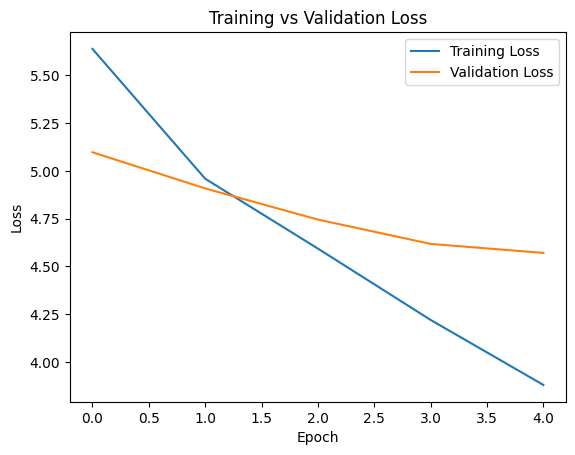

In [174]:
# Visualisasi Hasil Training (Loss dan Validation Loss)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [175]:
# Penyimpanan Model dan Riwayat Training
import pickle

with open(os.path.join(MODEL_DIR, "history.pkl"), "wb") as f:
    pickle.dump(history.history, f)

model.save(os.path.join(MODEL_DIR, "model_final.h5"))

print("Training completed!")


Training completed!


In [176]:
# tambahkan sel untuk memprediksi citra pengujian citra dengan 5 citra yang berbeda
# tambahkan Data 